In [9]:
import torch
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load YOLOv5s model (small, pre-trained on COCO)
model = torch.hub.load('ultralytics/yolov5', 'yolov5s', trust_repo=True)

Using cache found in /home/kalfin/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-5-2 Python-3.11.12 torch-2.7.0+cu126 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [3]:
# Load your image
img_path = 'img/one_person.jpg'
img = cv2.imread(img_path)

In [4]:
# Run inference
results = model(img)

/home/kalfin/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [5]:
# Show results
results.print()

image 1/1: 360x487 1 person
Speed: 21.2ms pre-process, 155.0ms inference, 8.8ms NMS per image at shape (1, 3, 480, 640)


In [6]:
# Only draw boxes for 'person' class
person_results = results.pandas().xyxy[0]
person_results = person_results[person_results['name'] == 'person']

In [7]:
# Draw bounding boxes
for _, row in person_results.iterrows():
    x1, y1, x2, y2 = int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax'])
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, 'person', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)

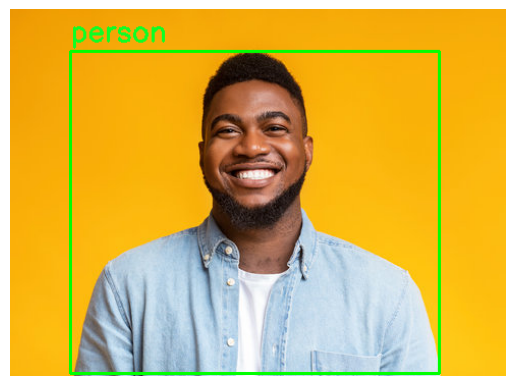

In [11]:
# Show the image
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()